### task 1

# Классификация при помощи ДПР

# Описание набора данных

В этой лабораторной работе мы рассмотрим разные подходы к задаче классификации, в частности, деревья принятия решений, а также поговорим о том, как бороться с несбалансированностью датасета.

Изучаемый нами набор данных — это набор данных о принятых предложениях по кредитам в банке **Thera-Bank**. Основные клиенты банка пользуются банком для того, чтобы разместить в нем свои денежные средства, то есть являются вкладчиками. В то же время, большую прибыль банку приносят кредиторы — люди, берущие в банке кредит. Поэтому банк хочет сформировать для своих вкладчиков выгодные предложения по кредиту. Кампания, проведенная банком для вкладчиков в прошлом году, показала, что коэффициент конверсии составил более 9,6%. Это побудило отдел маркетинга разработать кампании с улучшенным целевым маркетингом, чтобы увеличить вероятность успеха при, естественно, минимальном бюджете. Департамент хотел бы разработать классификатор, который поможет им определить потенциальных клиентов, которые с большей вероятностью приобретут кредит. Это повысит вероятность успеха при одновременном снижении стоимости кампании.

Набор данных содержит как информацию о клиенте, так и информацию о его реакции на кампанию предыдущего года:

*   **ID**: ID клиента

*   **Age**: Возраст (полных лет)

*   **Experience**: Стаж

*   **Income**: Годовой доход (в тысячах)

*   **ZIP Code**: Индекс места проживания

*   **Family**: Количество членов семьи

*   **CCAvg**: Средние траты в месяц по кредитной карте (в тысячах)

*   **Education**: Уровень образования (1: бакалавр, 2: магистр, 3: что-то большее)

*   **Mortgage**: Стоимость ипотеки, если имеется (в тысячах)

*   **Securities Account**: Наличие счета в ценных бумагах

*   **CD Account**: Наличие сертификата на депозит

*   **Online**: Использует ли клиент интернет-банкинг

*   **CreditCard**: Использует ли клиент кредитную карту, выпущенную данным банком

*   **Personal Loan**: Принял ли клиент персональное предложение по кредиту (целевая переменная)

In [251]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Разведочный анализ данных

Считайте набор данных в датафрейм

In [252]:
df = pd.read_csv("./data/Bank_Personal_Loan_Modelling_train.csv")

При помощи метода <code>.describe()</code> изучите набор данных «с высоты птичьего полета».

In [253]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000
mean,2497.682500,45.429500,20.196250,73.479750,93156.583750,2.381750,1.921805,1.881500,55.968250,0.096000,0.104000,0.061500,0.599000,0.29050
std,1449.723807,11.489235,11.500143,46.321345,2197.762636,1.149716,1.738974,0.842102,101.054887,0.294628,0.305299,0.240275,0.490162,0.45405
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1245.750000,35.000000,10.000000,38.000000,91941.750000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,2492.500000,45.000000,20.000000,63.000000,93407.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000
75%,3767.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,100.000000,0.000000,0.000000,0.000000,1.000000,1.00000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Набор данных содержит 14 переменных, 1 из которых является целевой.

1 номинальная переменная: **ID**

5 числовых переменных: **Age**, **Experience**, **Income**, **CCAvg**, **Mortgage**

3 категориальные переменных: **Family**, **Education**, **ZIP Code**

5 булевых переменных: **Personal Loan**, **Securities Account**, **CD Account**, **Online**, **CreditCard**

Пропущенных значений нет.

Experience содержит какие-то отрицательные значения

Удалите колонку ID, она нам не понадобится

In [254]:
df = df.drop(columns = ['ID'])
df.head()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,60,36,89,91745,2,2.8,1,0,0,0,0,1,0
1,44,19,30,91423,1,0.5,3,0,0,0,0,1,0
2,26,0,19,93014,1,0.1,2,121,0,0,0,1,0
3,34,9,41,92101,2,0.1,1,161,0,0,0,1,1
4,56,32,51,92780,4,1.5,1,0,0,0,0,0,0


Имеет смысл попробовать отловить каике-либо зависимости или их отсутствие.

Постройте матрицу корреляций

In [255]:
corr_mtx = df.corr()
corr_mtx

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.994134,-0.047440,-0.030978,-0.033864,-0.040827,0.027489,-0.003468,-0.018537,0.000950,0.013890,0.027305,0.014137
Experience,0.994134,1.000000,-0.037976,-0.029845,-0.040127,-0.038459,-0.001394,-0.000700,-0.018108,0.000239,0.016445,0.026962,0.015945
Income,-0.047440,-0.037976,1.000000,-0.015647,-0.156319,0.641660,-0.192029,0.197115,0.497333,0.005082,0.179584,0.013222,0.008567
ZIP Code,-0.030978,-0.029845,-0.015647,1.000000,0.006110,-0.003104,-0.019697,0.003173,-0.007605,-0.000667,0.008082,0.008478,0.001413
Family,-0.033864,-0.040127,-0.156319,0.006110,1.000000,-0.103654,0.070498,-0.024184,0.063050,0.011535,0.019090,0.011682,0.010254
CCAvg,-0.040827,-0.038459,0.641660,-0.003104,-0.103654,1.000000,-0.133361,0.104529,0.365553,0.028449,0.145242,-0.003718,0.004311
Education,0.027489,-0.001394,-0.192029,-0.019697,0.070498,-0.133361,1.000000,-0.028436,0.134556,-0.013329,0.012545,-0.018219,-0.015894
Mortgage,-0.003468,-0.000700,0.197115,0.003173,-0.024184,0.104529,-0.028436,1.000000,0.140203,-0.002341,0.093418,0.007982,-0.002726
Personal Loan,-0.018537,-0.018108,0.497333,-0.007605,0.063050,0.365553,0.134556,0.140203,1.000000,0.030758,0.336931,0.010362,0.010184
Securities Account,0.000950,0.000239,0.005082,-0.000667,0.011535,0.028449,-0.013329,-0.002341,0.030758,1.000000,0.325264,0.014732,-0.021373


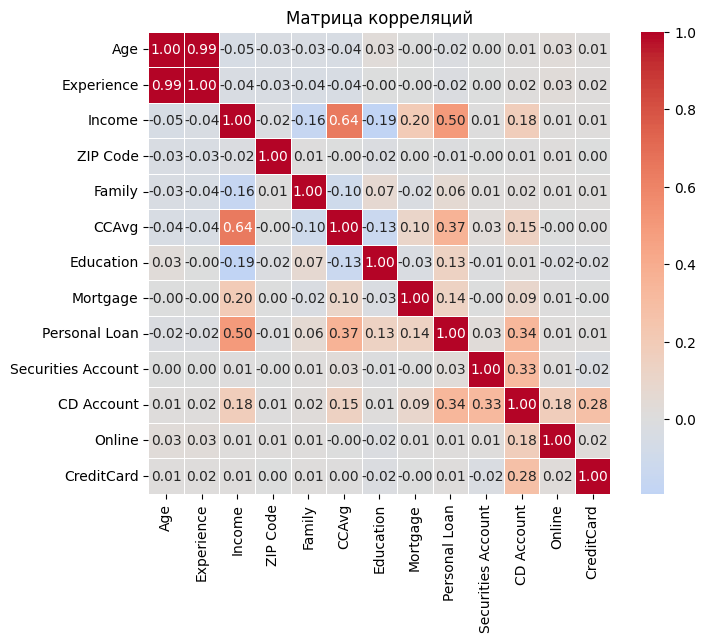

In [256]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_mtx, annot = True, cmap = 'coolwarm', center = 0,
            square = True, fmt = '.2f', linewidths = 0.5)
plt.title('Матрица корреляций')
plt.show()

Определите две наиболее коррелированных переменных

In [257]:
n = len(corr_mtx)
max_corr = 0
max_i, max_j = None, None

for i in range(n):
    for j in range(i + 1, n):
        current_corr = np.abs(corr_mtx.iloc[i, j])
        if current_corr > max_corr:
            max_corr = current_corr
            max_i, max_j = i, j

print(f"Максимальная корреляция: {max_corr:.4f}")
print(f"Индексы: i = {max_i}, j = {max_j}")
print(f"Значения: {corr_mtx.index[max_i]} и {corr_mtx.columns[max_j]}")

Максимальная корреляция: 0.9941
Индексы: i = 0, j = 1
Значения: Age и Experience


Определите признак, который меньше всего коррелирует (можно считать почти не коррелирует) с остальными признаками (в том числе с откликом). Удалите этот признак из рассмотрения.

Введите название удаленного признака.

In [258]:
min_mean_corr = float('inf')
min_i = None

for i in range(n):
    current_corr = np.abs(corr_mtx.iloc[i, i + 1:]).mean()
    if current_corr < min_mean_corr:
        min_mean_corr = current_corr
        min_i = i

print(f"Значение: {corr_mtx.index[min_i]}")

Значение: ZIP Code


In [259]:
df = df.drop(columns = ['ZIP Code'])

# Предварительная подготовка данных

## Модификация признаков

Стоит разобраться с полем <code>Experience</code>. Видно, что опыт коррелирует с возрастом. Однако, в поле <code>Experience</code> присутствуют отрицательные значения. Имеет смысл "сдвинуть" значения в этой колонке. Добавьте ко всем значениям колонки <code>Experience</code> одно число так, чтобы минимальное значение было равно $0$.

Вычислите выборочное среднее колонки <code>Experience</code> после преобразования.

In [260]:
min_val = np.abs(df['Experience'].min())
df['Experience'] = df['Experience'] + min_val

f"{df['Experience'].mean():.3f}"

'23.196'

Аналогично имеет смысл модфицировать поле <code>CCAvg</code>. Раз рассматривается годовой доход, то имеет смысл и значения трат рассматривать в рамках года.

Вычислите выборочное среднее колонки <code>CCAvg</code> после преобразования.

In [261]:
df['CCAvg'] = df['CCAvg'] * 12

f"{df['CCAvg'].mean():.3f}"

'23.062'

## Определение выбросов

Постройте ящики с усами для всех предикторов. Рекомендуем использовать <code>sns.boxplot()</code>. Определите признак по изображению boxplot из вашего варианта.

<AxesSubplot: >

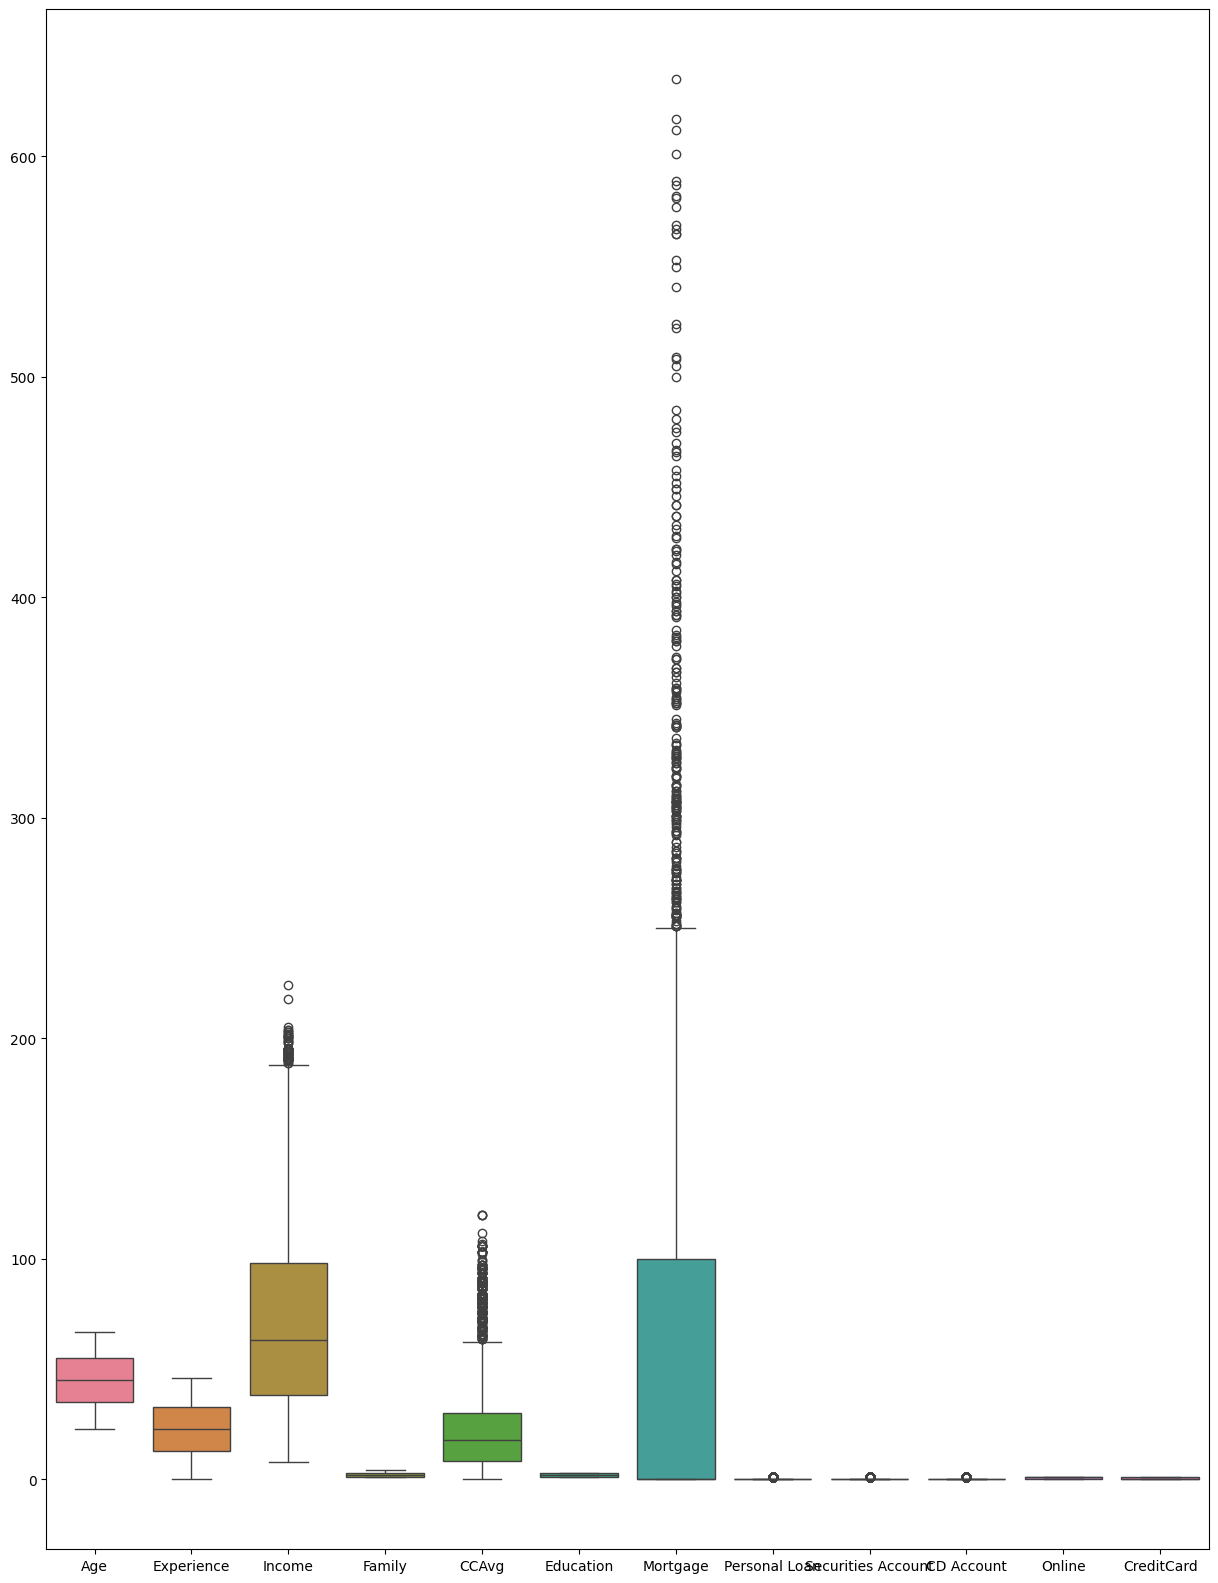

In [262]:
plt.figure(figsize=(15, 20))
sns.boxplot(df)

Определите признак, содержащий наибольшее число выбросов. Введите название этого признака.


In [263]:
# columns = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
# max_blowouts = 0
# max_col = None

# for col in columns:
#     if pd.api.types.is_numeric_dtype(df[col]) and len(df[col].unique()) > 2:
        
#         q1 = df[col].quantile(0.25)
#         q3 = df[col].quantile(0.75)

#         iqr = q3 - q1
#         lower = q1 - 1.5 * iqr
#         upper = q3 + 1.5 * iqr
        
#         cur_blowouts = ((df[col] < lower) | (df[col] > upper)).sum()
#         print(col, cur_blowouts)
#         if cur_blowouts > max_blowouts:
#             max_blowouts = cur_blowouts
#             max_col = col

max_col = 'Mortgage'
print(f"Значение: {max_col}")

Значение: Mortgage


Имеет смысл поработать с этим признаком, а для этого стоит руководствоваться следующими статистическими соображениями. Если вычесть из данных выборочное среднее, а после поделить на среднеквадратическое отклонение, то, пользуясь правилом 3-$\sigma$ для нормального распределения, можно выбросить слишком далекие от нуля хвосты. Постройте гистограмму распределения значений в рамках этого признака.

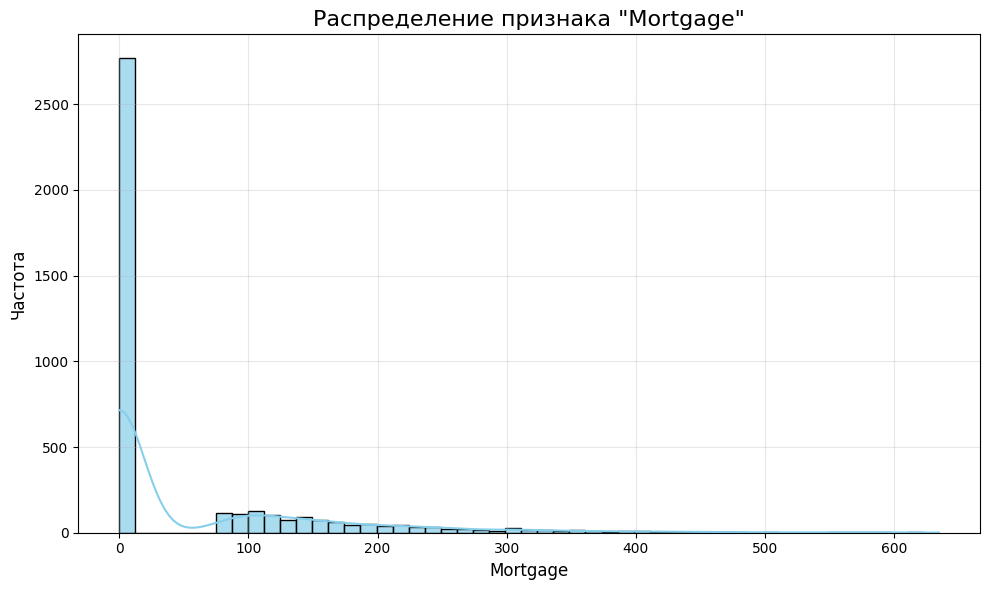

In [264]:
plt.figure(figsize = (10, 6))
sns.histplot(data = df, x = max_col, kde = True, color = 'skyblue', alpha = 0.7)

plt.title(f'Распределение признака "{max_col}"', fontsize = 16)
plt.xlabel(max_col, fontsize = 12)
plt.ylabel('Частота', fontsize = 12)

plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

Очевидно в рамках этого признака есть небольшое количество значений, которые лежат далеко. Можно использовать <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.html"><code>z-score</code></a> функцию из библиотеки <code>scipy</code>. 

Вспомнив курс теории вероятностей, становится понятно, что около $99.7\%$ нормального распределения сождержатся в отрезке $[-3\sigma, 3\sigma]$. Определите число элементов, модуль <code>z-score</code> которых больше, чем $3$. 

In [265]:
z_scores = stats.zscore(df[max_col])
cnt_elems = np.sum((np.abs(z_scores) > 3))
cnt_elems

83

In [266]:
df.shape[0]

4000

Итак, выбросов не очень множко, поэтому выбросите их из набора данных. Введите оставшееся в датасете число строк.

In [267]:
mask = np.abs(z_scores) <= 3
valid_indices = df[max_col].index[mask]

df = df.loc[valid_indices]
df.shape[0]

3917

# Построение моделей

# Базовый алгоритм

При помощи <code>train_test_split</code> разобейте полученный набор данных на тренеровочную и тестовую выборки с параметрами, указанными в вашем варианте.

In [268]:
X = df.drop(columns = ['Personal Loan'])
y = df['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, 
                                                    random_state = 23, 
                                                    stratify = y)

Обучите модель <code>DecisionTreeClassifier</code> с параметрами, указанными в вашем варианте на тренировочных данных, оцените на тестовых. Вычислите <code>f1_score</code> модели на тестовых данных.

In [269]:
clf = DecisionTreeClassifier(random_state = 23, criterion = 'entropy').fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [270]:
f"{f1_score(y_test, y_pred):.3f}"

'0.896'

In [271]:
clf = DecisionTreeClassifier(random_state = 23, criterion = 'gini').fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [272]:
f"{f1_score(y_test, y_pred):.3f}"

'0.876'

## Учет дисбаланса соотношения классов

А теперь, если вспомнить, что выборка несбалансирована, то можно указать дополнительный параметр <code>class_weight</code>. Обучите модель <code>DecisionTreeClassifier</code> с параметрами, указанными в вашем варианте на тренировочных данных, оцените на тестовых. Вычислите <code>f1_score</code> модели на тестовых данных.

In [273]:
clf = DecisionTreeClassifier(random_state = 23, criterion = 'gini', class_weight = 'balanced').fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [274]:
f"{f1_score(y_test, y_pred):.3f}"

'0.887'

In [275]:
clf = DecisionTreeClassifier(random_state = 23, criterion = 'entropy', class_weight = 'balanced').fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [276]:
f"{f1_score(y_test, y_pred):.3f}"

'0.881'

### task 2

In [349]:
df_train = pd.read_csv("./data/Bank_Personal_Loan_Modelling_train.csv")
df_test = pd.read_csv("./data/Bank_Personal_Loan_Modelling_reserved.csv")

In [350]:
df_train = df_train.drop(columns = ['ZIP Code', 'ID'])
df_test = df_test.drop(columns = ['ZIP Code', 'ID'])

In [351]:
z_scores = stats.zscore(df_train['Mortgage'])

mask = np.abs(z_scores) <= 3
valid_indices = df_train['Mortgage'].index[mask]

df_train = df_train.loc[valid_indices]

In [352]:
df_train['CCAvg'] = df_train['CCAvg'] * 12
df_test['CCAvg'] = df_test['CCAvg'] * 12

In [353]:
X = df_train.drop(columns = ['Personal Loan'])
y = df_train['Personal Loan']

In [ ]:
clf = DecisionTreeClassifier(random_state = 23, criterion = 'entropy').fit(X, y)
y_pred = clf.predict(df_test)

In [357]:
print(*y_pred.astype(int), sep = ", ")

0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0